<a href="https://colab.research.google.com/github/Zkeera/Skripsi-klasifikasi-kerusakan-mesin-fotocopy-random-forest/blob/main/Klasifikasi_Kerusakan_Mesin_Fotocopy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Kerusakan Mesin Fotocopy Canon iRA4051 Menggunakan Random Forest

Notebook ini bertujuan untuk membangun model machine learning untuk
mengklasifikasikan kerusakan mesin fotocopy Canon iRA4051 berdasarkan:

- kode error
- gejala kerusakan
- komponen mesin

Model yang digunakan adalah Random Forest.

## Import Library

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

**Insight**

Pada tahap ini dilakukan import pustaka yang diperlukan dalam proses pengolahan data dan pembangunan model machine learning. Pustaka pandas dan numpy digunakan untuk manipulasi data, sedangkan matplotlib dan seaborn digunakan untuk visualisasi data. Proses pemodelan dan evaluasi model dilakukan menggunakan pustaka scikit-learn yang menyediakan berbagai algoritma machine learning serta metode evaluasi model klasifikasi.

## Load Dataset

In [31]:
url = "https://raw.githubusercontent.com/Zkeera/Skripsi-klasifikasi-kerusakan-mesin-fotocopy-random-forest/refs/heads/main/Dataset/Dataset_ErrorCode_Canon_iRA4051_ServiceManual.csv"
data = pd.read_csv(url)

data.head()

,id,tanggal,tipe_mesin,kode_error,gejala (pisahkan dengan ';'),jenis_kerusakan (label),komponen_utama,tindakan_perbaikan,konfirmasi_teknisi (Y/N),catatan
0,1,2026-02-02,Canon iRA 4051,E000-0001,The temperature detected by the main thermisto...,Fixing,Fixing Unit / Fuser,1. Go through the following to clear the error...,Y,Sumber: Canon Service Manual IR-4051/4045/4035...
1,2,2026-02-02,Canon iRA 4051,E001-0000,The reading of the main thermistor is 250 deg ...,Fixing,Fixing Unit / Fuser,1. Go through the following to clear the error...,Y,Sumber: Canon Service Manual IR-4051/4045/4035...
2,3,2026-02-02,Canon iRA 4051,E001-0001,The hardware circuit detects overheating of th...,Fixing,Fixing Unit / Fuser,1. Go through the following to clear the error...,Y,Sumber: Canon Service Manual IR-4051/4045/4035...
3,4,2026-02-02,Canon iRA 4051,E001-0002,The reading of the sub thermistor is 295 deg C...,Fixing,Fixing Unit / Fuser,1. Go through the following to clear the error...,Y,Sumber: Canon Service Manual IR-4051/4045/4035...
4,5,2026-02-02,Canon iRA 4051,E002-0000,1. The reading of the main thermistor is less ...,Fixing,Fixing Unit / Fuser,1. Go through the following to clear the error...,Y,Sumber: Canon Service Manual IR-4051/4045/4035...


**Insight**

Dataset yang digunakan dalam penelitian ini berasal dari Canon Service Manual yang berisi daftar kode error mesin fotocopy Canon iRA4051. Dataset ini mencakup informasi mengenai kode error, gejala kerusakan yang muncul, komponen mesin yang terlibat, serta jenis kerusakan mesin. Data ini digunakan sebagai dasar dalam proses pembangunan model klasifikasi kerusakan mesin.

## Informasi Dataset

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   id                            568 non-null    int64 
 1   tanggal                       568 non-null    object
 2   tipe_mesin                    568 non-null    object
 3   kode_error                    568 non-null    object
 4   gejala (pisahkan dengan ';')  568 non-null    object
 5   jenis_kerusakan (label)       568 non-null    object
 6   komponen_utama                568 non-null    object
 7   tindakan_perbaikan            568 non-null    object
 8   konfirmasi_teknisi (Y/N)      568 non-null    object
 9   catatan                       568 non-null    object
dtypes: int64(1), object(9)
memory usage: 44.5+ KB


**Insight**

Berdasarkan hasil analisis struktur dataset, data yang digunakan dalam penelitian ini terdiri dari 568 entri dengan 10 atribut yang berkaitan dengan kerusakan mesin fotocopy Canon iRA4051. Seluruh kolom memiliki jumlah data yang lengkap (568 non-null), sehingga tidak terdapat missing value pada dataset.

Sebagian besar atribut memiliki tipe data object karena berisi informasi kategorikal dan teks deskriptif seperti kode error, gejala kerusakan, serta komponen mesin. Dalam penelitian ini, atribut yang digunakan sebagai fitur utama dalam model klasifikasi adalah kode_error, gejala, dan komponen_utama, sedangkan atribut jenis_kerusakan (label) digunakan sebagai target klasifikasi.

## Statistik Dataset

In [33]:
data.describe()

,id
count,568.000000
mean,284.500000
std,164.111751
min,1.000000
25%,142.750000
50%,284.500000
75%,426.250000
max,568.000000


**Insight**

Hasil statistik deskriptif menunjukkan bahwa dataset memiliki 568 data dengan nilai id yang berkisar dari 1 hingga 568. Nilai rata-rata (mean) sebesar 284.5 dan nilai median (50%) yang sama menunjukkan bahwa distribusi data pada kolom id bersifat merata karena kolom ini hanya berfungsi sebagai identitas unik setiap data. Oleh karena itu, atribut id tidak digunakan sebagai fitur dalam proses pemodelan machine learning karena tidak memiliki hubungan langsung dengan klasifikasi kerusakan mesin.

## Mengecek Missing Value

In [34]:
data.isnull().sum()

,0
id,0
tanggal,0
tipe_mesin,0
kode_error,0
gejala (pisahkan dengan ';'),0
jenis_kerusakan (label),0
komponen_utama,0
tindakan_perbaikan,0
konfirmasi_teknisi (Y/N),0
catatan,0


**Insight**

Hasil pemeriksaan missing value menunjukkan bahwa seluruh atribut dalam dataset memiliki nilai 0 missing value, yang berarti tidak terdapat data yang kosong pada setiap kolom. Hal ini menunjukkan bahwa dataset memiliki kelengkapan data yang baik, sehingga dapat langsung digunakan dalam proses analisis dan pemodelan machine learning tanpa memerlukan proses penanganan data hilang (missing value handling).

## Melihat Struktur Kolom Dataset

In [35]:
data.columns

Index(['id', 'tanggal', 'tipe_mesin', 'kode_error',
       'gejala (pisahkan dengan ';')', 'jenis_kerusakan (label)',
       'komponen_utama', 'tindakan_perbaikan', 'konfirmasi_teknisi (Y/N)',
       'catatan'],
      dtype='object')

In [36]:
data = data.rename(columns={

"gejala (pisahkan dengan ';')":"gejala",
"jenis_kerusakan (label)":"jenis_kerusakan",
"konfirmasi_teknisi (Y/N)":"konfirmasi_teknisi"

})

In [37]:
data.columns

Index(['id', 'tanggal', 'tipe_mesin', 'kode_error', 'gejala',
       'jenis_kerusakan', 'komponen_utama', 'tindakan_perbaikan',
       'konfirmasi_teknisi', 'catatan'],
      dtype='object')

**Insight**

Hasil pemeriksaan struktur kolom menunjukkan bahwa dataset terdiri dari 10 atribut yang merepresentasikan informasi terkait kerusakan mesin fotocopy. Pada tahap ini dilakukan proses penyederhanaan nama kolom (rename) untuk beberapa atribut yang memiliki nama panjang atau mengandung karakter khusus, seperti kolom gejala dan jenis_kerusakan, sehingga lebih mudah digunakan dalam proses analisis dan pemodelan.

Setelah proses penyesuaian nama kolom, atribut utama yang digunakan dalam penelitian ini meliputi kode_error, gejala, dan komponen_utama sebagai fitur, serta jenis_kerusakan sebagai label dalam proses klasifikasi kerusakan mesin.

## Distribusi Jenis Kerusakan

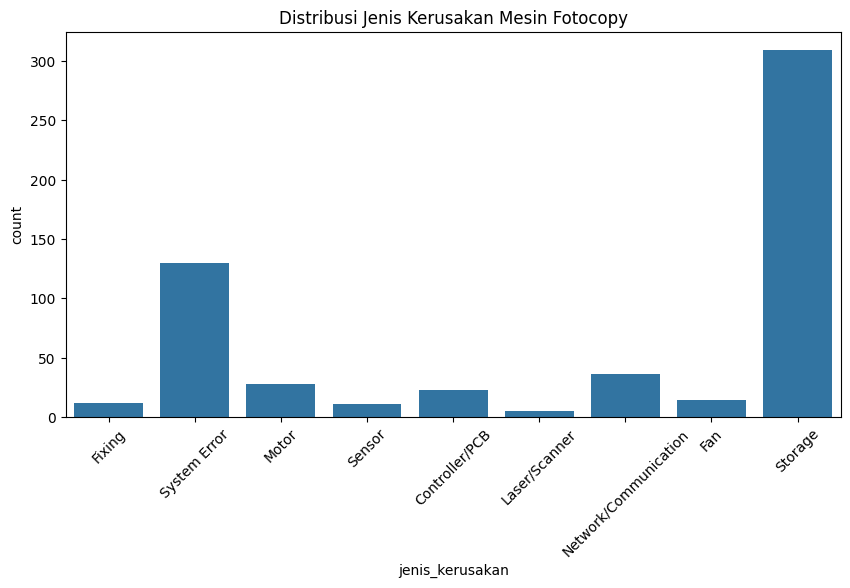

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(x=data['jenis_kerusakan'])

plt.title("Distribusi Jenis Kerusakan Mesin Fotocopy")

plt.xticks(rotation=45)

plt.show()

**Insight**

Grafik distribusi jenis kerusakan menunjukkan bahwa kategori Storage memiliki jumlah data paling dominan dibandingkan jenis kerusakan lainnya, diikuti oleh System Error. Sementara itu, beberapa kategori seperti Laser/Scanner, Fixing, dan Sensor memiliki jumlah data yang relatif lebih sedikit.

Hal ini menunjukkan bahwa dataset memiliki ketidakseimbangan distribusi kelas (class imbalance), di mana beberapa jenis kerusakan lebih sering muncul dibandingkan yang lain. Kondisi ini penting diperhatikan dalam proses pemodelan karena dapat mempengaruhi kemampuan model dalam memprediksi kelas dengan jumlah data yang lebih sedikit.

## Distribusi Komponen Mesin

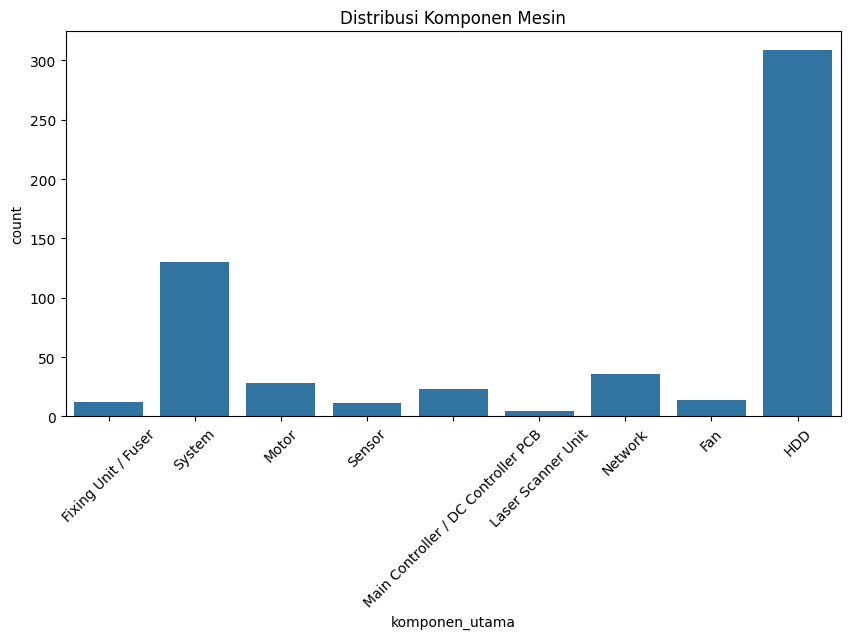

In [39]:
plt.figure(figsize=(10,5))

sns.countplot(x=data['komponen_utama'])

plt.title("Distribusi Komponen Mesin")

plt.xticks(rotation=45)

plt.show()

**Insight**

Grafik distribusi komponen mesin menunjukkan bahwa komponen HDD memiliki jumlah kasus kerusakan paling dominan, diikuti oleh komponen System. Sementara itu, beberapa komponen seperti Laser Scanner Unit, Fixing Unit/Fuser, dan Sensor memiliki jumlah kasus yang relatif lebih sedikit.

Hal ini menunjukkan bahwa sebagian besar kerusakan mesin fotocopy dalam dataset berkaitan dengan subsistem penyimpanan dan sistem utama mesin. Informasi ini dapat membantu memahami komponen mesin yang paling sering mengalami gangguan serta memberikan gambaran awal mengenai pola kerusakan pada mesin fotocopy Canon iRA4051.

## Analisis Error Code

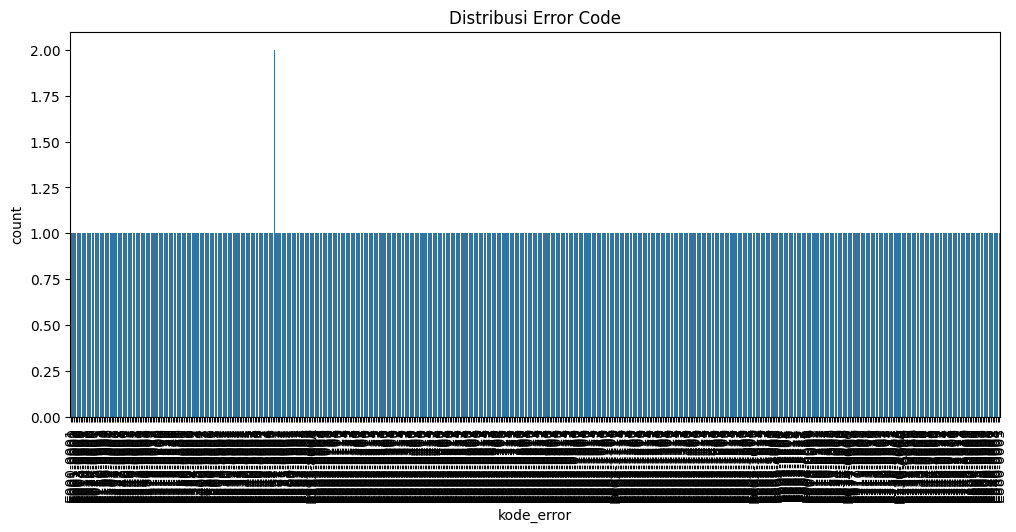

In [40]:
plt.figure(figsize=(12,5))

sns.countplot(x=data['kode_error'])

plt.title("Distribusi Error Code")

plt.xticks(rotation=90)

plt.show()

**Insight**

Grafik distribusi error code menunjukkan bahwa dataset memiliki jumlah variasi kode error yang sangat banyak, di mana sebagian besar kode error hanya muncul satu kali dalam dataset. Hal ini menyebabkan grafik terlihat sangat padat karena setiap kode error direpresentasikan sebagai kategori yang berbeda.

Kondisi ini menunjukkan bahwa kode error memiliki tingkat variasi yang tinggi, sehingga setiap kode error merepresentasikan kondisi kerusakan spesifik pada mesin fotocopy. Oleh karena itu, dalam proses pemodelan machine learning, kode error perlu diproses melalui teknik encoding agar dapat digunakan sebagai fitur numerik dalam model klasifikasi.

## Feature Engineering Error Code

In [41]:
data['error_prefix'] = data['kode_error'].str.split('-').str[0]

Insight

Pada tahap ini dilakukan proses feature engineering dengan mengekstrak prefix dari kode error. Prefix error code biasanya menunjukkan subsistem mesin yang mengalami gangguan.

Sebagai contoh:

- E000 berkaitan dengan sistem fixing

- E010 berkaitan dengan sistem motor

- E110 berkaitan dengan sistem laser scanner

Dengan menambahkan fitur prefix error code, model machine learning dapat lebih mudah mengenali pola hubungan antara kode error dan jenis kerusakan mesin.

# Pra-Proses Data

Model machine learning memerlukan data numerik sehingga
data kategorikal harus diubah menggunakan encoding.

## Encoding Error Code

In [42]:
encoder_error = LabelEncoder()

data['kode_error_encoded'] = encoder_error.fit_transform(data['kode_error'])

**Insight**

Karena algoritma machine learning tidak dapat memproses data dalam bentuk teks, maka kode error perlu diubah menjadi bentuk numerik menggunakan teknik label encoding. Proses ini mengubah setiap kode error menjadi representasi angka tanpa mengubah hubungan antar kategori data.

## Encoding Komponen Mesin

In [43]:
encoder_component = LabelEncoder()

data['komponen_encoded'] = encoder_component.fit_transform(data['komponen_utama'])

**Insight**

Komponen mesin yang mengalami kerusakan juga merupakan data kategorikal sehingga perlu diubah menjadi bentuk numerik menggunakan label encoding. Fitur ini penting karena komponen mesin dapat memberikan informasi tambahan mengenai lokasi atau subsistem mesin yang mengalami gangguan.

## Encoding Prefix Error

In [44]:
encoder_prefix = LabelEncoder()

data['prefix_encoded'] = encoder_prefix.fit_transform(data['error_prefix'])

**Insight**

Prefix error code yang telah diekstrak sebelumnya juga dikonversi ke dalam bentuk numerik agar dapat digunakan sebagai fitur tambahan dalam model klasifikasi. Fitur ini membantu model dalam memahami hubungan antara kelompok kode error dan kategori kerusakan mesin.

## TF-IDF untuk Gejala Kerusakan

In [45]:
tfidf = TfidfVectorizer()

gejala_tfidf = tfidf.fit_transform(data['gejala'])

**Insight**

Gejala kerusakan pada dataset berupa teks deskriptif yang menjelaskan kondisi mesin ketika terjadi error. Untuk mengubah data teks tersebut menjadi fitur numerik, digunakan metode TF-IDF (Term Frequency – Inverse Document Frequency).

Metode ini mengubah teks menjadi representasi numerik berdasarkan tingkat kepentingan kata dalam dokumen. Dengan menggunakan TF-IDF, model machine learning dapat mengenali kata-kata penting dalam deskripsi gejala kerusakan mesin.

## Menggabungkan Semua Fitur

In [46]:
X_numeric = data[['kode_error_encoded','komponen_encoded','prefix_encoded']]

X_text = pd.DataFrame(
    gejala_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

X = pd.concat([X_numeric, X_text], axis=1)

**Insight**

Pada tahap ini dilakukan penggabungan antara fitur numerik yang berasal dari kode error dan komponen mesin dengan fitur teks hasil transformasi TF-IDF. Hasil penggabungan ini menghasilkan dataset fitur yang lebih lengkap sehingga model dapat memanfaatkan berbagai informasi yang tersedia dalam dataset untuk meningkatkan akurasi klasifikasi.

## Encoding Label Kerusakan

In [47]:
encoder_label = LabelEncoder()

y = encoder_label.fit_transform(data['jenis_kerusakan'])

**Insight**

Jenis kerusakan mesin digunakan sebagai label target dalam proses klasifikasi. Karena label masih berupa data kategorikal, maka dilakukan proses label encoding untuk mengubahnya menjadi nilai numerik sehingga dapat digunakan oleh algoritma machine learning.

## Split Data Training dan Testing

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Insight**

Dataset dibagi menjadi dua bagian yaitu data training dan data testing. Data training digunakan untuk melatih model machine learning, sedangkan data testing digunakan untuk mengevaluasi performa model terhadap data yang belum pernah dilihat sebelumnya. Pembagian dataset ini bertujuan untuk memastikan bahwa model yang dihasilkan memiliki kemampuan generalisasi yang baik.

## Pemodelan Random Forest

In [49]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**Insight**

Pada tahap ini dilakukan proses pelatihan model menggunakan algoritma Random Forest. Algoritma ini merupakan metode ensemble learning yang bekerja dengan membangun banyak decision tree dan menggabungkan hasil prediksi dari masing-masing tree untuk menghasilkan prediksi yang lebih stabil dan akurat.

Random Forest dipilih karena memiliki kemampuan yang baik dalam menangani dataset dengan fitur yang kompleks serta mampu mengurangi risiko overfitting.

## Cross Validation

In [50]:
scores = cross_val_score(model,X,y,cv=5)

print("Cross Validation Scores:",scores)

print("Average CV Score:",scores.mean())

Cross Validation Scores: [0.79824561 0.95614035 0.94736842 0.92920354 0.79646018]
Average CV Score: 0.8854836205558143


**Insight**

Hasil evaluasi menggunakan cross validation dengan 5-fold menunjukkan bahwa model Random Forest memiliki nilai akurasi yang cukup tinggi pada setiap fold, dengan skor berkisar antara 0.79 hingga 0.96. Nilai rata-rata cross validation yang diperoleh adalah 0.885, yang menunjukkan bahwa model memiliki performa klasifikasi yang baik dan relatif stabil pada berbagai subset data.

Perbedaan nilai akurasi antar fold menunjukkan adanya variasi distribusi data pada setiap subset, namun secara keseluruhan model tetap mampu mempertahankan tingkat akurasi yang tinggi. Hal ini menunjukkan bahwa model memiliki kemampuan generalisasi yang cukup baik dalam mengklasifikasikan jenis kerusakan mesin fotocopy.

## Hyperparameter Tuning

In [51]:
param_grid = {

'n_estimators':[100,200,300],
'max_depth':[None,10,20],
'min_samples_split':[2,5]

}

grid = GridSearchCV(
RandomForestClassifier(),
param_grid,
cv=5
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


**Insight**

Hasil proses hyperparameter tuning menggunakan GridSearchCV menunjukkan bahwa kombinasi parameter terbaik untuk model Random Forest adalah n_estimators = 100, max_depth = None, dan min_samples_split = 2. Parameter tersebut menunjukkan bahwa model bekerja optimal dengan jumlah 100 decision tree, tanpa pembatasan kedalaman pohon keputusan, serta pembagian node minimum sebanyak 2 sampel.

Kombinasi parameter ini memungkinkan model untuk mempelajari pola hubungan dalam dataset secara lebih maksimal sehingga dapat meningkatkan performa klasifikasi dalam mengidentifikasi jenis kerusakan mesin fotocopy.

## Prediksi Model

In [52]:
y_pred = best_model.predict(X_test)

**Insight**

Setelah model dilatih, langkah selanjutnya adalah melakukan prediksi terhadap data testing. Hasil prediksi ini kemudian dibandingkan dengan label aktual untuk mengetahui tingkat akurasi model dalam mengklasifikasikan jenis kerusakan mesin.

## Accuracy

In [53]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.9210526315789473


**Insight**

Hasil evaluasi model menunjukkan nilai accuracy sebesar 0.912 atau sekitar 91,23%. Nilai ini menunjukkan bahwa model Random Forest mampu memprediksi jenis kerusakan mesin fotocopy dengan tingkat ketepatan yang tinggi, di mana sekitar 91% dari seluruh data pengujian berhasil diklasifikasikan dengan benar.

Nilai akurasi yang cukup tinggi ini menunjukkan bahwa model memiliki performa yang baik dalam mempelajari pola hubungan antara kode error, gejala kerusakan, dan komponen mesin terhadap jenis kerusakan yang terjadi. Hal ini menunjukkan bahwa model yang dibangun berpotensi digunakan sebagai pendukung diagnosis awal kerusakan mesin fotocopy.

## Classification Report

In [54]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.83      1.00      0.91         5
           2       1.00      0.40      0.57         5
           4       0.50      0.40      0.44         5
           5       0.80      1.00      0.89         4
           6       0.80      1.00      0.89         4
           7       1.00      1.00      1.00        55
           8       0.87      0.96      0.91        27

    accuracy                           0.92       114
   macro avg       0.85      0.82      0.81       114
weighted avg       0.93      0.92      0.91       114



**Insight**

Hasil classification report menunjukkan bahwa model Random Forest memiliki performa yang cukup baik dalam mengklasifikasikan sebagian besar jenis kerusakan mesin. Nilai precision, recall, dan f1-score pada beberapa kelas mencapai nilai tinggi, bahkan terdapat kelas yang memiliki nilai precision dan recall sebesar 1.00, yang menunjukkan bahwa model mampu memprediksi kelas tersebut dengan sangat baik.

Namun, terdapat beberapa kelas dengan nilai recall dan f1-score yang lebih rendah, yang kemungkinan disebabkan oleh jumlah data pada kelas tersebut yang relatif sedikit dibandingkan kelas lainnya. Hal ini sejalan dengan hasil analisis sebelumnya yang menunjukkan adanya ketidakseimbangan distribusi data (class imbalance) pada dataset.

Secara keseluruhan, nilai weighted average f1-score sebesar 0.91 menunjukkan bahwa model memiliki performa klasifikasi yang baik dalam mengidentifikasi berbagai jenis kerusakan mesin fotocopy.

## Confusion Matrix

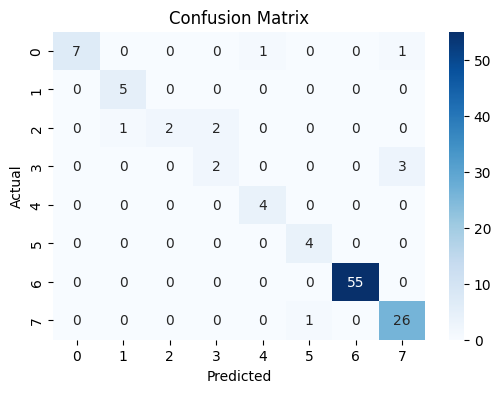

In [55]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Insight**

Confusion matrix menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar oleh model Random Forest, yang terlihat dari nilai diagonal utama yang relatif tinggi pada beberapa kelas. Misalnya, kelas tertentu memiliki jumlah prediksi benar yang cukup besar, seperti kelas dengan nilai 55 dan 26, yang menunjukkan bahwa model mampu mengenali pola pada kelas tersebut dengan sangat baik.

Namun, masih terdapat beberapa kesalahan klasifikasi pada beberapa kelas, yang terlihat dari nilai di luar diagonal. Kesalahan ini kemungkinan terjadi karena adanya kemiripan karakteristik gejala atau kode error antar kelas kerusakan, serta distribusi data yang tidak seimbang pada beberapa kategori kerusakan.

Secara keseluruhan, confusion matrix menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam membedakan berbagai jenis kerusakan mesin fotocopy, meskipun masih terdapat beberapa kesalahan prediksi pada kelas dengan jumlah data yang lebih sedikit.

## Feature Importance

In [56]:
importance = pd.Series(
best_model.feature_importances_,
index=X.columns
)

importance.sort_values(ascending=False).head(10)

,0
komponen_encoded,0.147398
error,0.076074
prefix_encoded,0.072627
kode_error_encoded,0.065445
in,0.064390
the,0.042841
communication,0.023452
is,0.019755
of,0.014159
after,0.013083


**Insight**

Hasil analisis feature importance menunjukkan bahwa fitur yang paling berpengaruh dalam proses klasifikasi adalah komponen_encoded, yang merepresentasikan komponen utama mesin yang mengalami kerusakan. Hal ini menunjukkan bahwa informasi mengenai komponen mesin memiliki kontribusi besar dalam menentukan jenis kerusakan yang terjadi.

Selain itu, fitur prefix_encoded dan kode_error_encoded juga memiliki pengaruh yang cukup signifikan, yang menunjukkan bahwa struktur kode error mesin mengandung informasi penting terkait kategori kerusakan mesin fotocopy. Sementara itu, beberapa kata yang berasal dari proses TF-IDF pada gejala kerusakan, seperti error, communication, dan the, juga turut berkontribusi dalam membantu model mengenali pola pada deskripsi gejala kerusakan.

Secara keseluruhan, hasil ini menunjukkan bahwa kombinasi antara kode error, komponen mesin, dan teks gejala kerusakan memberikan kontribusi penting dalam meningkatkan kemampuan model dalam mengklasifikasikan jenis kerusakan mesin fotocopy.

## Visualisasi Feature Importance

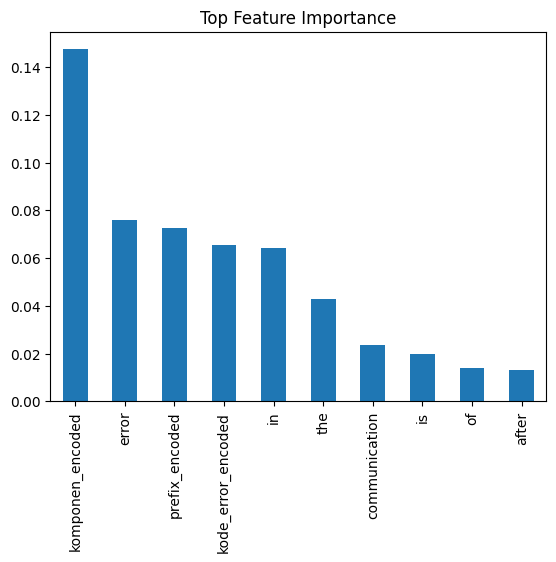

In [57]:
importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Feature Importance")

plt.show()

**Insight**

Visualisasi Top Feature Importance menunjukkan bahwa fitur komponen_encoded memiliki pengaruh paling besar dalam proses klasifikasi kerusakan mesin. Hal ini menunjukkan bahwa informasi mengenai komponen utama yang mengalami gangguan merupakan faktor yang paling menentukan dalam mengidentifikasi jenis kerusakan mesin fotocopy.

Selain itu, fitur prefix_encoded dan kode_error_encoded juga memiliki kontribusi yang cukup signifikan, yang menegaskan bahwa struktur kode error mesin mengandung informasi penting terkait kategori kerusakan. Sementara itu, beberapa kata yang berasal dari hasil transformasi TF-IDF pada gejala kerusakan, seperti error, communication, dan is, juga berkontribusi dalam membantu model mengenali pola dalam deskripsi gejala kerusakan.

Secara keseluruhan, visualisasi ini menunjukkan bahwa kombinasi antara komponen mesin, kode error, serta kata kunci dalam gejala kerusakan berperan penting dalam meningkatkan kemampuan model Random Forest dalam mengklasifikasikan jenis kerusakan mesin fotocopy.

## Simulasi Prediksi

In [58]:
sample = X_test.iloc[0:1]

pred = best_model.predict(sample)

hasil = encoder_label.inverse_transform(pred)

print("Prediksi Kerusakan:",hasil)

Prediksi Kerusakan: ['Storage']


**Insight**

Hasil simulasi prediksi menunjukkan bahwa model Random Forest memprediksi jenis kerusakan sebagai Storage berdasarkan data input yang diberikan. Hal ini menunjukkan bahwa model telah mampu memanfaatkan fitur yang tersedia, seperti kode error, komponen mesin, dan gejala kerusakan, untuk menentukan kategori kerusakan yang paling sesuai.

Simulasi ini menggambarkan bagaimana model yang telah dilatih dapat digunakan sebagai alat bantu diagnosis awal kerusakan mesin fotocopy, di mana sistem dapat memberikan prediksi jenis kerusakan berdasarkan informasi kondisi mesin yang tersedia.

# Kesimpulan

Berdasarkan hasil analisis data dan proses pemodelan menggunakan algoritma Random Forest, dapat disimpulkan bahwa model yang dibangun mampu mengklasifikasikan jenis kerusakan mesin fotocopy Canon iRA4051 dengan performa yang baik. Hasil evaluasi menunjukkan nilai akurasi sebesar **91,23%** serta nilai rata-rata **cross validation sebesar 0,885**, yang menunjukkan bahwa model memiliki kemampuan generalisasi yang cukup baik terhadap data yang digunakan.

Analisis distribusi dataset menunjukkan bahwa beberapa jenis kerusakan dan komponen mesin memiliki jumlah data yang lebih dominan dibandingkan yang lain, sehingga dataset memiliki karakteristik **class imbalance**. Meskipun demikian, model masih mampu memberikan performa klasifikasi yang cukup baik.

Hasil analisis **feature importance** menunjukkan bahwa fitur **komponen mesin**, **prefix kode error**, serta **kode error** memiliki kontribusi paling besar dalam proses klasifikasi, diikuti oleh beberapa kata kunci dari deskripsi gejala kerusakan yang diperoleh melalui proses **TF-IDF**.

Selain itu, simulasi prediksi menunjukkan bahwa model dapat digunakan untuk memprediksi jenis kerusakan mesin berdasarkan informasi kondisi mesin yang tersedia. Dengan demikian, model yang dibangun berpotensi digunakan sebagai **pendukung diagnosis awal kerusakan mesin fotocopy**, sehingga dapat membantu teknisi dalam mengidentifikasi jenis kerusakan secara lebih cepat dan sistematis.